In [7]:
import os
from jiwer import wer, cer

# ✅ correct paths
truth_path = "datasets/transcripts"
pred_path = "datasets/asr_text"

files = []
wer_scores = []
cer_scores = []

for file in os.listdir(truth_path):
    if file.endswith(".txt"):

        truth_file = os.path.join(truth_path, file)
        pred_file = os.path.join(pred_path, file)

        # ✅ skip if prediction missing
        if not os.path.exists(pred_file):
            print(f"Missing prediction for: {file}")
            continue

        # ✅ safe reading with UTF-8
        with open(truth_file, encoding="utf-8", errors="ignore") as f:
            truth = f.read().lower()

        with open(pred_file, encoding="utf-8", errors="ignore") as f:
            pred = f.read().lower()

        # ✅ compute scores
        file_wer = wer(truth, pred)
        file_cer = cer(truth, pred)

        files.append(file)
        wer_scores.append(file_wer)
        cer_scores.append(file_cer)

        print(f"{file} → WER: {file_wer:.3f} | CER: {file_cer:.3f}")

# ✅ overall results
print("\n========== SUMMARY ==========")
print("Files evaluated:", len(files))
print("Average WER:", round(sum(wer_scores)/len(wer_scores), 3))
print("Average CER:", round(sum(cer_scores)/len(cer_scores), 3))


audio1.txt → WER: 0.372 | CER: 0.134
audio10.txt → WER: 0.485 | CER: 0.238
audio11.txt → WER: 0.335 | CER: 0.084
audio12.txt → WER: 0.441 | CER: 0.071
audio13.txt → WER: 0.258 | CER: 0.105
audio14.txt → WER: 0.213 | CER: 0.084
audio15.txt → WER: 0.625 | CER: 0.363
audio16.txt → WER: 0.385 | CER: 0.101
audio17.txt → WER: 0.450 | CER: 0.103
audio2.txt → WER: 0.283 | CER: 0.110
audio3.txt → WER: 0.297 | CER: 0.115
audio4.txt → WER: 0.310 | CER: 0.103
audio5.txt → WER: 0.218 | CER: 0.084
audio6.txt → WER: 0.679 | CER: 0.422
audio7.txt → WER: 0.254 | CER: 0.085
audio8.txt → WER: 0.341 | CER: 0.129
audio9.txt → WER: 0.248 | CER: 0.180

========== SUMMARY ==========
Files evaluated: 17
Average WER: 0.364
Average CER: 0.148


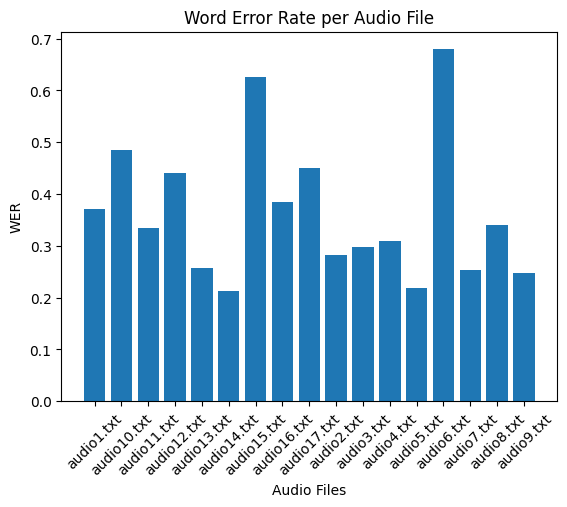

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(files, wer_scores)
plt.xticks(rotation=45)
plt.title("Word Error Rate per Audio File")
plt.xlabel("Audio Files")
plt.ylabel("WER")
plt.show()


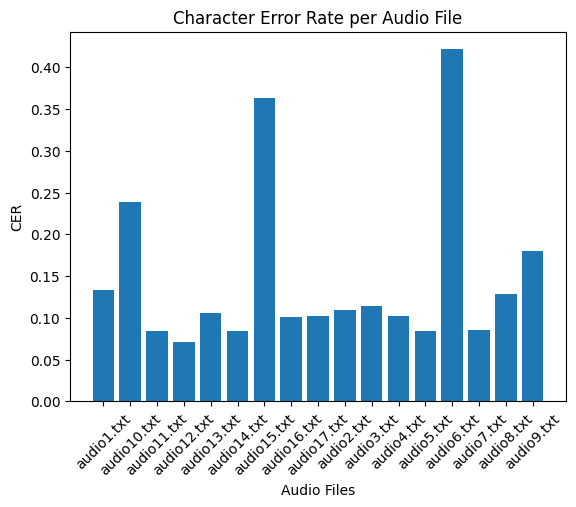

In [9]:
plt.figure()
plt.bar(files, cer_scores)
plt.xticks(rotation=45)
plt.title("Character Error Rate per Audio File")
plt.xlabel("Audio Files")
plt.ylabel("CER")
plt.show()


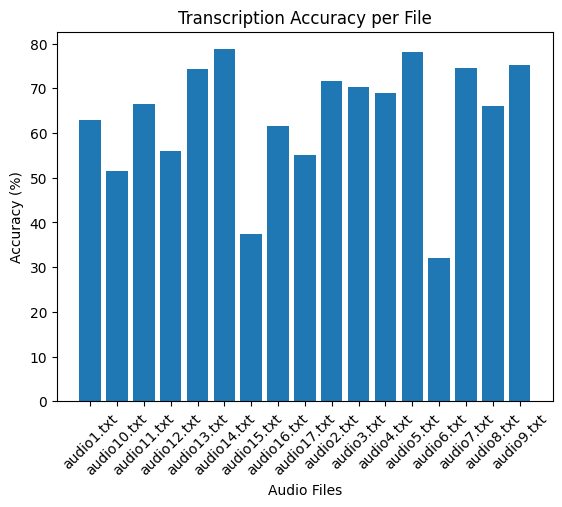

In [10]:
accuracy = [(1 - w) * 100 for w in wer_scores]

plt.figure()
plt.bar(files, accuracy)
plt.xticks(rotation=45)
plt.title("Transcription Accuracy per File")
plt.xlabel("Audio Files")
plt.ylabel("Accuracy (%)")
plt.show()


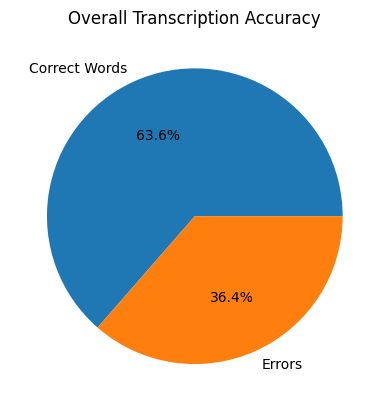

In [11]:
avg_wer = sum(wer_scores)/len(wer_scores)

labels = ['Correct Words', 'Errors']
sizes = [1-avg_wer, avg_wer]

plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Overall Transcription Accuracy")
plt.show()


In [12]:
from jiwer import process_words
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

truth_path = "datasets/transcripts/audio1.txt"
pred_path = "datasets/asr_text/audio1.txt"

with open(truth_path, encoding="utf-8", errors="ignore") as f:
    truth = clean(f.read())

with open(pred_path, encoding="utf-8", errors="ignore") as f:
    pred = clean(f.read())

result = process_words(truth, pred)

print("Substitutions:", result.substitutions)
print("Insertions:", result.insertions)
print("Deletions:", result.deletions)


Substitutions: 1480
Insertions: 914
Deletions: 148
